NEURAL NETWORKS FROM SCRATCH - XOR PROBLEM

1. PERCEPTRON
AND: [0 0 0 1]
OR: [0 1 1 1]
XOR: [1 1 0 0] -> Perceptron fails!

2. TWO-LAYER NN
XOR Result: [0 1 1 0]

3. COMPARISON
Hidden neurons: 2 -> Accuracy: 100%
Hidden neurons: 4 -> Accuracy: 100%
Hidden neurons: 8 -> Accuracy: 100%


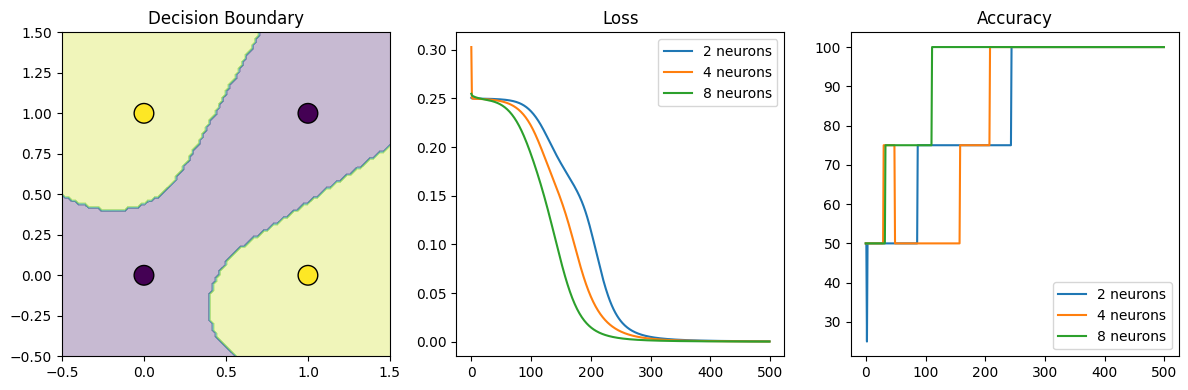

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ================= PART A: PERCEPTRON =================
class Perceptron:
    def __init__(self):
        self.weights = None
        self.bias = 0

    def train(self, X, y, epochs=20):
        self.weights = np.zeros(X.shape[1])
        for _ in range(epochs):
            for i in range(len(X)):
                prediction = 1 if np.dot(X[i], self.weights) + self.bias >= 0 else 0
                error = y[i] - prediction
                self.weights += error * X[i]
                self.bias += error

    def predict(self, X):
        return np.array([
            1 if np.dot(x, self.weights) + self.bias >= 0 else 0 for x in X
        ])


# ================= PART B: 2-LAYER NEURAL NETWORK =================
class TwoLayerNN:
    def __init__(self):
        self.W1 = np.random.randn(2, 4) * 0.5
        self.b1 = np.zeros(4)
        self.W2 = np.random.randn(4, 1) * 0.5
        self.b2 = np.zeros(1)

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def train(self, X, y, epochs=5000):
        y = y.reshape(-1, 1)
        for _ in range(epochs):
            # Forward
            hidden = self.sigmoid(np.dot(X, self.W1) + self.b1)
            output = self.sigmoid(np.dot(hidden, self.W2) + self.b2)

            # Backward
            output_error = output - y
            hidden_error = output_error.dot(self.W2.T) * hidden * (1 - hidden)

            # Update
            self.W2 -= 0.5 * hidden.T.dot(output_error)
            self.b2 -= 0.5 * np.sum(output_error, axis=0)
            self.W1 -= 0.5 * X.T.dot(hidden_error)
            self.b1 -= 0.5 * np.sum(hidden_error, axis=0)

    def predict(self, X):
        hidden = self.sigmoid(np.dot(X, self.W1) + self.b1)
        output = self.sigmoid(np.dot(hidden, self.W2) + self.b2)
        return (output > 0.5).astype(int).flatten()


# ================= PART C: SIMPLE KERAS-LIKE =================
class SimpleKeras:
    def __init__(self, hidden_neurons):
        self.W1 = np.random.randn(2, hidden_neurons) * 0.5
        self.b1 = np.zeros(hidden_neurons)
        self.W2 = np.random.randn(hidden_neurons, 1) * 0.5
        self.b2 = np.zeros(1)
        self.losses = []
        self.accuracies = []

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def fit(self, X, y, epochs=1000):
        y = y.reshape(-1, 1)
        for _ in range(epochs):
            hidden = self.sigmoid(np.dot(X, self.W1) + self.b1)
            output = self.sigmoid(np.dot(hidden, self.W2) + self.b2)

            loss = np.mean((y - output) ** 2)
            self.losses.append(loss)

            acc = np.mean((output > 0.5) == y) * 100
            self.accuracies.append(acc)

            d_output = output - y
            d_hidden = d_output.dot(self.W2.T) * hidden * (1 - hidden)

            self.W2 -= 0.5 * hidden.T.dot(d_output)
            self.b2 -= 0.5 * np.sum(d_output)
            self.W1 -= 0.5 * X.T.dot(d_hidden)
            self.b1 -= 0.5 * np.sum(d_hidden, axis=0)

    def predict(self, X):
        hidden = self.sigmoid(np.dot(X, self.W1) + self.b1)
        return (self.sigmoid(np.dot(hidden, self.W2) + self.b2) > 0.5).astype(int).flatten()


# ================= MAIN PROGRAM =================
print("=" * 60)
print("NEURAL NETWORKS FROM SCRATCH - XOR PROBLEM")
print("=" * 60)

# Dataset
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_and = np.array([0, 0, 0, 1])
y_or = np.array([0, 1, 1, 1])
y_xor = np.array([0, 1, 1, 0])

# ---- Perceptron ----
print("\n1. PERCEPTRON")
p = Perceptron()

p.train(X, y_and)
print("AND:", p.predict(X))

p.train(X, y_or)
print("OR:", p.predict(X))

p.train(X, y_xor)
print("XOR:", p.predict(X), "-> Perceptron fails!")


# ---- Two Layer NN ----
print("\n2. TWO-LAYER NN")
nn = TwoLayerNN()
nn.train(X, y_xor)
print("XOR Result:", nn.predict(X))


# ---- Compare Architectures ----
print("\n3. COMPARISON")
for neurons in [2, 4, 8]:
    model = SimpleKeras(neurons)
    model.fit(X, y_xor)
    pred = model.predict(X)
    accuracy = np.mean(pred == y_xor) * 100
    print(f"Hidden neurons: {neurons} -> Accuracy: {accuracy:.0f}%")


# ---- Visualization ----
plt.figure(figsize=(12, 4))

# Decision Boundary
plt.subplot(1, 3, 1)
model_viz = SimpleKeras(4)
model_viz.fit(X, y_xor)

xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 100),
                     np.linspace(-0.5, 1.5, 100))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = model_viz.predict(grid).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y_xor, s=200, edgecolor='black')
plt.title("Decision Boundary")

# Loss
plt.subplot(1, 3, 2)
for neurons in [2, 4, 8]:
    m = SimpleKeras(neurons)
    m.fit(X, y_xor, epochs=500)
    plt.plot(m.losses, label=f"{neurons} neurons")
plt.legend()
plt.title("Loss")

# Accuracy
plt.subplot(1, 3, 3)
for neurons in [2, 4, 8]:
    m = SimpleKeras(neurons)
    m.fit(X, y_xor, epochs=500)
    plt.plot(m.accuracies, label=f"{neurons} neurons")
plt.legend()
plt.title("Accuracy")

plt.tight_layout()
plt.show()

In [3]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split

np.random.seed(0)

data = load_iris()
X = data.data
y = data.target.reshape(-1, 1)

scaler = StandardScaler()
X = scaler.fit_transform(X)

encoder = OneHotEncoder(sparse_output=False)
y = encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

def softmax(x):
    exp = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp / np.sum(exp, axis=1, keepdims=True)

class NeuralNetwork:
    def __init__(self):
        self.W1 = np.random.randn(4, 8) * 0.1
        self.b1 = np.zeros((1, 8))
        self.W2 = np.random.randn(8, 3) * 0.1
        self.b2 = np.zeros((1, 3))

        self.mW1 = np.zeros_like(self.W1)
        self.vW1 = np.zeros_like(self.W1)
        self.mW2 = np.zeros_like(self.W2)
        self.vW2 = np.zeros_like(self.W2)

    def forward(self, X):
        self.z1 = X @ self.W1 + self.b1
        self.a1 = sigmoid(self.z1)
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = softmax(self.z2)
        return self.a2

    def backward(self, X, y, lr=0.01, beta1=0.9, beta2=0.999, eps=1e-8):
        m = X.shape[0]

        dz2 = self.a2 - y
        dW2 = (self.a1.T @ dz2) / m
        db2 = np.sum(dz2, axis=0, keepdims=True) / m

        dz1 = (dz2 @ self.W2.T) * sigmoid_derivative(self.a1)
        dW1 = (X.T @ dz1) / m
        db1 = np.sum(dz1, axis=0, keepdims=True) / m

        self.mW1 = beta1 * self.mW1 + (1 - beta1) * dW1
        self.vW1 = beta2 * self.vW1 + (1 - beta2) * (dW1 ** 2)
        self.mW2 = beta1 * self.mW2 + (1 - beta1) * dW2
        self.vW2 = beta2 * self.vW2 + (1 - beta2) * (dW2 ** 2)

        self.W1 -= lr * self.mW1 / (np.sqrt(self.vW1) + eps)
        self.W2 -= lr * self.mW2 / (np.sqrt(self.vW2) + eps)
        self.b1 -= lr * db1
        self.b2 -= lr * db2

    def train(self, X, y, epochs=2000):
        for _ in range(epochs):
            self.forward(X)
            self.backward(X, y)

    def predict(self, X):
        probs = self.forward(X)
        return np.argmax(probs, axis=1)

nn = NeuralNetwork()
nn.train(X_train, y_train)

pred = nn.predict(X_test)
true = np.argmax(y_test, axis=1)

accuracy = np.mean(pred == true) * 100
print("Accuracy:", accuracy)

Accuracy: 96.66666666666667
